# <center>PRIDE: PRIvacy through DEniability</center>

--- PRIDE Initialization (n=3, K=2) ---
Initial D has 5 shares. Key base r has 6 elements.

--- Running Benchmarks ---
Dataset size: 1000 | Total encryption time: 0.088s | Total decoy time: 0.181s | Ciphertext length: 3005
Dataset size: 5000 | Total encryption time: 0.310s | Total decoy time: 0.659s | Ciphertext length: 15005
Dataset size: 10000 | Total encryption time: 0.721s | Total decoy time: 1.397s | Ciphertext length: 30005
Dataset size: 50000 | Total encryption time: 3.892s | Total decoy time: 7.715s | Ciphertext length: 150005
Dataset size: 100000 | Total encryption time: 8.496s | Total decoy time: 16.432s | Ciphertext length: 300005

--- Generating Plots ---
Saved: pride_plots/scalability.png
Saved: pride_plots/encryption_time.png
Saved: pride_plots/decoy_time.png
Saved: pride_plots/storage.png

--- Demonstrating Retrieval Mechanism with the last PRIDE instance ---
Retrieved (real) message: 918
Actual 'real' message (if its key was chosen): 851


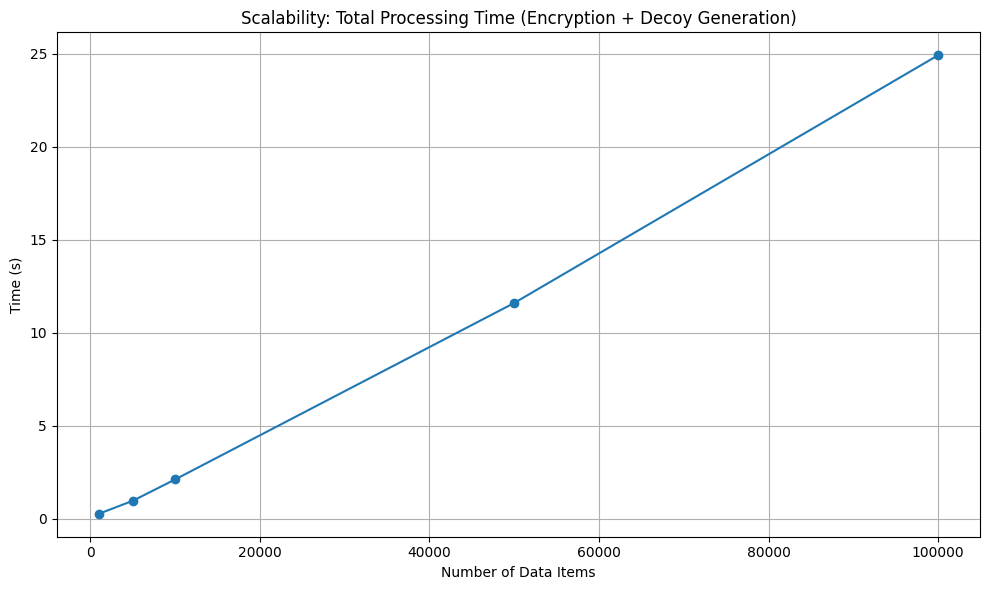

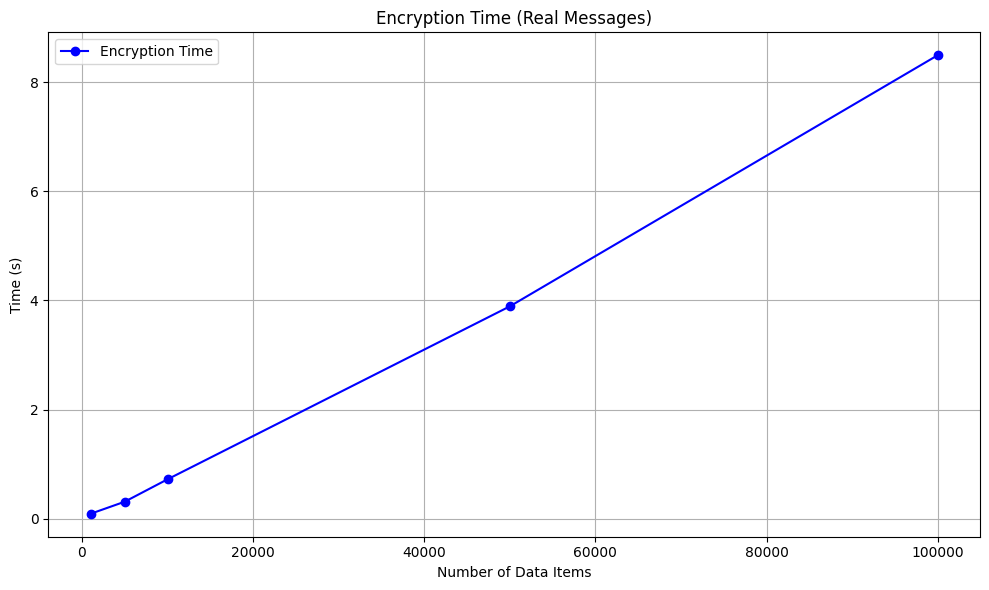

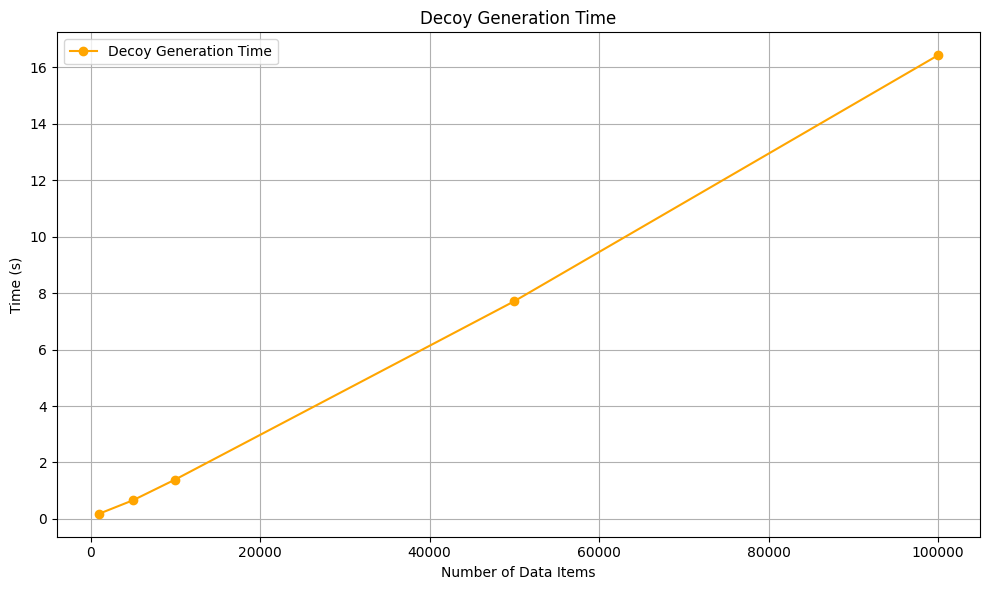

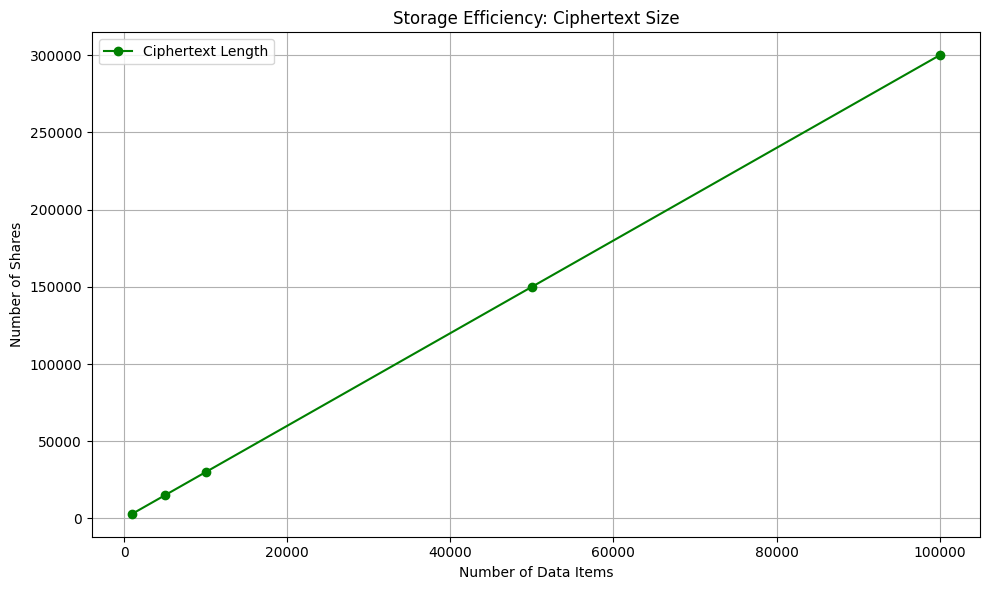

In [5]:
import random
import numpy as np
import time
import os
from functools import reduce
from typing import Tuple, List, Any

# Create a directory for plots if it doesn't exist
os.makedirs("pride_plots", exist_ok=True)

# --- Modular Arithmetic Functions ---
# A moderately large prime for our finite field.
p = 2305843009213693951  # 2^61 - 1

def mod_add(a: int, b: int) -> int:
    return (a + b) % p

def mod_mul(a: int, b: int) -> int:
    return (a * b) % p

def mod_inv(a: int) -> int:
    # Compute modular inverse using Fermat's little theorem: a^(p-2) mod p
    # Assumes p is prime and a is not 0 mod p
    if a == 0:
        raise ValueError("Cannot compute modular inverse of 0.")
    return pow(a, p - 2, p)

# --- Lagrange Interpolation ---
def lagrange_interpolate(x: int, xs: List[int], ys: List[int]) -> int:
    """
    Perform Lagrange interpolation to compute polynomial evaluated at x.
    xs and ys are the known data points (x-coordinates and y-coordinates).
    """
    total = 0
    k = len(xs)
    if k == 0:
        raise ValueError("Cannot interpolate with no data points.")
    if len(xs) != len(ys):
        raise ValueError("xs and ys must have the same length.")

    for i in range(k):
        xi, yi = xs[i], ys[i]
        li = 1  # Lagrange basis polynomial for point i
        for j in range(k):
            if i == j:
                continue
            xj = xs[j]
            
            denominator = mod_add(xi, -xj % p)
            if denominator == 0:
                raise ValueError(f"Lagrange interpolation error: duplicate x-coordinate {xi} at index {j} for xi={xi}, xj={xj}")
            
            numerator = mod_add(x, -xj % p)
            li = mod_mul(li, mod_mul(numerator, mod_inv(denominator)))

        total = mod_add(total, mod_mul(yi, li))
    return total

# --- Helper for Gaussian Elimination (for solving linear system for coefficients) ---
def solve_linear_system(matrix: List[List[int]], vector: List[int], modulus: int) -> List[int]:
    n = len(matrix)
    if n == 0: # Handle empty system (e.g., for degree 0 poly)
        return []
    if n != len(vector):
        raise ValueError("Matrix must be square and match vector length.")

    # Create an augmented matrix
    augmented_matrix = [row + [vector[i]] for i, row in enumerate(matrix)]

    for i in range(n):
        # Find pivot (first non-zero element in column i from row i downwards)
        pivot_row = i
        while pivot_row < n and augmented_matrix[pivot_row][i] == 0:
            pivot_row += 1
        if pivot_row == n:
            raise ValueError("Matrix is singular or system has no unique solution.")

        # Swap rows to bring pivot to current row
        if pivot_row != i:
            augmented_matrix[i], augmented_matrix[pivot_row] = augmented_matrix[pivot_row], augmented_matrix[i]

        pivot_val = augmented_matrix[i][i]
        try:
            pivot_inv = mod_inv(pivot_val)
        except ValueError as e:
            raise ValueError(f"Failed to get modular inverse for pivot {pivot_val}: {e}")

        # Normalize the pivot row
        for j in range(i, n + 1):
            augmented_matrix[i][j] = mod_mul(augmented_matrix[i][j], pivot_inv)

        # Eliminate other rows
        for row_idx in range(n):
            if row_idx != i:
                factor = augmented_matrix[row_idx][i]
                for col_idx in range(i, n + 1):
                    augmented_matrix[row_idx][col_idx] = mod_add(
                        augmented_matrix[row_idx][col_idx],
                        -mod_mul(factor, augmented_matrix[i][col_idx]) % modulus
                    )

    # Extract the solution (coefficients)
    solutions = [augmented_matrix[i][n] for i in range(n)]
    return solutions

# --- PRIDE Class Implementation ---
class PRIDE:
    def __init__(self, n: int, K: int):
        """
        n: threshold for polynomial secret sharing (degree n-1 polynomial).
        K: number of decoys generated per real encryption.
        """
        if n < 2:
            raise ValueError("Threshold 'n' must be at least 2 for polynomial secret sharing.")
        if K < 1:
            raise ValueError("Decoy count 'K' must be at least 1.")
            
        self.n = n
        self.K = K
        self.params = {} # Store system parameters after setup
        self.D: List[int] = [] # Ciphertext D (list of field elements)
        self.r: List[int] = [] # Key base r (from PRIDE.Setup)
        # Secret keys stored as (label, (reconstruction_indices_D, indices_from_r))
        self.secret_keys: List[Tuple[str, Tuple[List[int], List[int]]]] = [] 

        # Initial setup called upon instantiation
        self.setup()

    def setup(self):
        """
        Implements Algorithm: PRIDE.Setup(λ, η, K)
        Initialises system parameters, including the finite field F, a secret key base r,
        and an empty (or initial) ciphertext D.
        λ is implicitly managed by choosing p (2^61-1) for a large field.
        η (threshold for secret sharing) is self.n.
        K (decoy count) is self.K.
        """
        # F = Zp (implicitly handled by modular arithmetic with p)
        # Randomize k (size of r) to prevent size leakage. Paper suggests k in [n, 2n].
        # For this simulation, we'll fix k_size based on n.
        k_size = self.n * 2 # Ensures enough r elements to choose `n` for secret key
        self.r = [random.randrange(0, p) for _ in range(k_size)]

        # D starts as empty in the paper's Setup. For simulation, adding initial random shares.
        # This simulates an existing state, making it not truly "empty" but "initial".
        init_shares_D = 5 
        # Ensure initial D has at least n-1 shares if we want to use existing shares for poly interpolation.
        # If n=3, we need at least 2 shares from D.
        if init_shares_D < self.n - 1:
            init_shares_D = self.n - 1 # Minimum to ensure initial state supports n-1 share selection

        self.D = [random.randrange(0, p) for _ in range(init_shares_D)]

        self.params = {
            "p": p,
            "n": self.n,
            "K": self.K,
            "r_size": k_size
        }
        # print(f"PRIDE System Setup Complete. Initial D has {len(self.D)} shares. Key base r has {len(self.r)} elements.")


    def _encrypt_single(self, m: int) -> Tuple[Tuple[List[int], List[int]], List[int]]:
        """
        Internal: encrypt a single message m using polynomial sharing.
        This now tries to align more closely with solving for polynomial coefficients
        to fit m at p(0) and existing D shares.
        Returns (secret_key, updated_D).
        secret_key: (reconstruction_indices_D, chosen_indices_from_r)
        """
        current_D_len = len(self.D)
        num_existing_indices_for_poly = self.n - 1 # Number of existing D shares needed for polynomial

        # Initialize chosen_indices_from_D and existing_y_points
        chosen_indices_from_D: List[int] = []
        existing_y_points: List[int] = []

        if current_D_len < num_existing_indices_for_poly:
            # Not enough existing shares in D. Use all available and pad with synthetic points.
            chosen_indices_from_D = list(range(1, current_D_len + 1))
            existing_y_points = [self.D[idx - 1] for idx in chosen_indices_from_D]

            # Generate unique synthetic indices and y-values
            start_synthetic_idx = max(current_D_len + 1, self.n + 1) # Ensure sufficiently large and unique
            for i in range(num_existing_indices_for_poly - current_D_len):
                synth_idx = start_synthetic_idx + i
                chosen_indices_from_D.append(synth_idx)
                existing_y_points.append(random.randrange(0, p)) # Random synthetic y-value

        else:
            # Enough existing shares in D, pick n-1 distinct indices.
            chosen_indices_from_D = sorted(random.sample(range(1, current_D_len + 1), num_existing_indices_for_poly))
            existing_y_points = [self.D[idx - 1] for idx in chosen_indices_from_D]

        # At this point, chosen_indices_from_D and existing_y_points are guaranteed to be populated
        # and of length num_existing_indices_for_poly.

        # 2. Setup the linear system for coefficients a_1, ..., a_{n-1}
        # The polynomial is p(x) = m + a_1*x + ... + a_{n-1}*x^(n-1) mod p
        # We know n points: (0, m) and (i_j, existing_y_points[j]) for the chosen n-1 indices.
        # Build the matrix for [a_1, ..., a_{n-1}] from p(i_j) - m = a_1*i_j + ... + a_{n-1}*i_j^(n-1)

        matrix = []
        vector = [] # Represents p(i_j) - m

        # For degree 0 polynomial (n=1), there are no coefficients a_1...
        if self.n > 1:
            for k_idx, i_j in enumerate(chosen_indices_from_D):
                row = []
                for power in range(1, self.n): # x^1, x^2, ..., x^(n-1)
                    row.append(pow(i_j, power, p))
                matrix.append(row)
                vector.append(mod_add(existing_y_points[k_idx], -m % p)) # y_j - m

            # Solve the linear system
            # coefficients will be [a_1, ..., a_{n-1}]
            try:
                coeffs = solve_linear_system(matrix, vector, p)
            except ValueError as e:
                # Fallback for systems that might be singular or have no unique solution
                print(f"Warning: Linear system solving for coefficients failed ({e}). Using random coefficients for simulation.")
                coeffs = [random.randrange(0, p) for _ in range(self.n - 1)]
        else: # n == 1, polynomial degree is 0, p(x) = m. No coefficients.
            coeffs = []


        # 3. Compute the new share a_{l+1} = p(l+1)
        new_share_idx = current_D_len + 1 # Paper uses l+1 for next index
        new_share_val = m # Start with p(0) = m

        for power in range(1, self.n):
            term = mod_mul(coeffs[power - 1], pow(new_share_idx, power, p))
            new_share_val = mod_add(new_share_val, term)

        # Append new share to D
        self.D.append(new_share_val)

        # 4. Select n indices from the key base r for the secret key.
        # This part aligns with FBE's notion of selecting r-values from the key base.
        # The paper: "select the set of indices i1,...,in to select the r-values from the key base"
        chosen_indices_from_r = sorted(random.sample(range(len(self.r)), self.n))

        # The secret key `sk` consists of the `n` x-coordinates that, together with their
        # corresponding y-values from D, can reconstruct the polynomial, AND
        # the indices from `r` that were part of its construction (for FBE).
        # For polynomial reconstruction: (0,m), (i_1, D[i_1-1]), ..., (i_{n-1}, D[i_{n-1}-1]), (l+1, a_{l+1})
        # The secret key stores the `n` x-coordinates needed for reconstruction including `new_share_idx`.
        reconstruction_indices_D = chosen_indices_from_D + [new_share_idx]
        
        sk = (reconstruction_indices_D, chosen_indices_from_r)
        return sk, self.D


    def PRIDE_enc(self, m: int, decoy_sampler: callable) -> Tuple[List[Tuple[str, Any]], float, float]:
        """
        Encrypts a real message m and adds K decoy encryptions into ciphertext D.
        decoy_sampler: a function that samples a decoy message from the empirical distribution.
        Returns a tuple: (list of all secret keys generated for this call,
        encryption time, decoy generation time)
        """
        keys: List[Tuple[str, Any]] = []
        start_time = time.time()

        # Encrypt the real message
        real_key, _ = self._encrypt_single(m)
        keys.append(('real', real_key))
        t_enc = time.time() - start_time

        # Generate and encrypt K decoys
        decoy_time = 0.0
        for _ in range(self.K):
            m_decoy = decoy_sampler()
            start_decoy = time.time()
            decoy_key, _ = self._encrypt_single(m_decoy)
            decoy_time += time.time() - start_decoy
            keys.append(('decoy', decoy_key))

        self.secret_keys.extend(keys)
        return keys, t_enc, decoy_time

    def PRIDE_dec(self, secret_key: Tuple[List[int], List[int]]) -> int:
        """
        Decrypt a message using the secret key.
        secret_key: (reconstruction_indices_D, chosen_indices_from_r)
        We assume the polynomial p(x) from encryption satisfies p(0) = m.
        """
        reconstruction_indices_D, _ = secret_key

        if len(reconstruction_indices_D) != self.n:
             raise ValueError(f"Decryption failed: Expected {self.n} reconstruction indices in key, got {len(reconstruction_indices_D)}.")

        # Filter out x=0 if it's explicitly in the key's indices, as it's the target point
        # The actual shares (y-values) are taken from self.D for non-zero indices.
        final_xs = []
        final_ys = []
        for x_coord in sorted(reconstruction_indices_D): # Sort for consistent interpolation
            if x_coord == 0:
                continue # We are evaluating at 0, not taking a share from D at index 0.

            # Validate index against current D length
            if x_coord - 1 < 0 or x_coord - 1 >= len(self.D):
                 raise ValueError(f"Decryption error: Share for index {x_coord} (0-indexed: {x_coord - 1}) not found in ciphertext D (length {len(self.D)}).")
            
            final_xs.append(x_coord)
            final_ys.append(self.D[x_coord - 1])
            
        # We need `n` points (x_i, y_i) to reconstruct a degree n-1 polynomial.
        # If one of the original `n` points for the key was `(0, m)`, and `n-1` from `D`,
        # then `final_xs` and `final_ys` should have `n-1` points. We then interpolate at 0.
        # This is the standard interpretation for p(0)=m.
        
        # However, the `reconstruction_indices_D` from `_encrypt_single` already includes
        # `n-1` from original `D` AND the `new_share_idx`. This means `reconstruction_indices_D`
        # itself should contain `n` x-coordinates whose y-values are in `self.D`.
        # So `final_xs` and `final_ys` should have length `self.n` if `0` wasn't included in the key's indices.
        
        # Let's adjust for the fact that `reconstruction_indices_D` *is* the list of `n` x-coords from D
        # needed to define the polynomial, from which we want p(0).
        # It should contain exactly `self.n` elements, all corresponding to indices in `self.D`.

        if len(final_xs) != self.n:
            # This indicates an issue if `0` was accidentally included in `reconstruction_indices_D`
            # or if `reconstruction_indices_D` didn't have `self.n` distinct non-zero indices.
            raise ValueError(f"Insufficient shares for Lagrange interpolation. Expected {self.n} points, got {len(final_xs)}.")
            
        m_rec = lagrange_interpolate(0, final_xs, final_ys)
        return m_rec


    def retrieval_mechanism(self) -> Tuple[str, int]:
        """
        Simulates the retrieval mechanism M(D).
        It selects one secret key sk* uniformly at random from the set of all available keys K,
        and then outputs the result of PRIDE.Dec(D, sk*, r, params).
        """
        if not self.secret_keys:
            raise ValueError("No keys available to retrieve from. Encrypt messages first.")

        # Choose a secret key uniformly at random
        chosen_label, sk_star = random.choice(self.secret_keys)

        # Decrypt using the chosen key
        retrieved_message = self.PRIDE_dec(sk_star)
        return chosen_label, retrieved_message

# --- Sampler Functions (consistent with paper's assumption of identical distribution) ---
def decoy_sampler_normal(mean: int = 1000, std: int = 100) -> int:
    # Sample a decoy from a normal distribution and convert to an integer mod p.
    # Ensure the sampled value is non-negative and within the field [0, p-1]
    m_sample = int(np.round(np.random.normal(mean, std)))
    return m_sample % p

def real_message_sampler(mean: int = 1000, std: int = 100) -> int:
    # For real messages, we can assume a similar distribution
    m_sample = int(np.round(np.random.normal(mean, std)))
    return m_sample % p

# --- Benchmarking and Example Execution ---
if __name__ == "__main__":
    # Set random seed for reproducibility
    random.seed(40)
    np.random.seed(40)

    # PRIDE parameters
    n_val = 3  # threshold for polynomial secret sharing (degree n-1 polynomial)
    K_val = 2  # Number of decoys generated per real encryption.

    print(f"--- PRIDE Initialization (n={n_val}, K={K_val}) ---")
    # Initial instance is just for display, benchmarks create new instances
    initial_pride_instance = PRIDE(n=n_val, K=K_val) 
    print(f"Initial D has {len(initial_pride_instance.D)} shares. Key base r has {len(initial_pride_instance.r)} elements.")


    # Dataset sizes for benchmarking
    dataset_sizes = [1000, 5000, 10000, 50000, 100000]
    encryption_times = []
    decoy_times = []
    ciphertext_sizes = []

    print("\n--- Running Benchmarks ---")
    last_benchmark_pride = None # Keep track of the last instance for demonstration
    
    for size in dataset_sizes:
        # Initialize a fresh instance for each benchmark run.
        benchmark_pride = PRIDE(n=n_val, K=K_val)
        total_enc_time = 0.0
        total_decoy_time = 0.0

        for _ in range(size):
            m = real_message_sampler()
            _, t_enc, t_decoy = benchmark_pride.PRIDE_enc(m, decoy_sampler_normal)
            total_enc_time += t_enc
            total_decoy_time += t_decoy
        
        last_benchmark_pride = benchmark_pride # Store the last instance

        encryption_times.append(total_enc_time)
        decoy_times.append(total_decoy_time)
        ciphertext_sizes.append(len(benchmark_pride.D))

        print(f"Dataset size: {size} | Total encryption time: {total_enc_time:.3f}s | "
              f"Total decoy time: {total_decoy_time:.3f}s | Ciphertext length: {len(benchmark_pride.D)}")

    # --- Plotting Benchmarks ---
    print("\n--- Generating Plots ---")
    import matplotlib.pyplot as plt # Import here if not at top to avoid dependency issues for non-plot runs
    
    # 1. Scalability: Total Processing Time
    plt.figure(figsize=(10, 6))
    total_processing_time = [e + d for e, d in zip(encryption_times, decoy_times)]
    plt.plot(dataset_sizes, total_processing_time, marker='o', label='Total Processing Time')
    plt.title("Scalability: Total Processing Time (Encryption + Decoy Generation)")
    plt.xlabel("Number of Data Items")
    plt.ylabel("Time (s)")
    plt.grid(True)
    plt.tight_layout()
    scalability_path = "pride_plots/scalability.png"
    plt.savefig(scalability_path, dpi=300)
    # plt.show() 
    print(f"Saved: {scalability_path}")

    # 2. Encryption Time (Real Messages)
    plt.figure(figsize=(10, 6))
    plt.plot(dataset_sizes, encryption_times, marker='o', color='blue', label='Encryption Time')
    plt.title("Encryption Time (Real Messages)")
    plt.xlabel("Number of Data Items")
    plt.ylabel("Time (s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    encryption_path = "pride_plots/encryption_time.png"
    plt.savefig(encryption_path, dpi=300)
    # plt.show()
    print(f"Saved: {encryption_path}")

    # 3. Decoy Generation Time
    plt.figure(figsize=(10, 6))
    plt.plot(dataset_sizes, decoy_times, marker='o', color='orange', label='Decoy Generation Time')
    plt.title("Decoy Generation Time")
    plt.xlabel("Number of Data Items")
    plt.ylabel("Time (s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    decoy_path = "pride_plots/decoy_time.png"
    plt.savefig(decoy_path, dpi=300)
    # plt.show()
    print(f"Saved: {decoy_path}")

    # 4. Storage Efficiency: Ciphertext Size
    plt.figure(figsize=(10, 6))
    plt.plot(dataset_sizes, ciphertext_sizes, marker='o', color='green', label='Ciphertext Length')
    plt.title("Storage Efficiency: Ciphertext Size")
    plt.xlabel("Number of Data Items")
    plt.ylabel("Number of Shares")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    storage_path = "pride_plots/storage.png"
    plt.savefig(storage_path, dpi=300)
    # plt.show()
    print(f"Saved: {storage_path}")

    print("\n--- Demonstrating Retrieval Mechanism with the last PRIDE instance ---")
    if last_benchmark_pride and last_benchmark_pride.secret_keys:
        label, decrypted_m = last_benchmark_pride.retrieval_mechanism()
        print(f"Retrieved ({label}) message: {decrypted_m}")

        # Try to find a 'real' message key if one exists and decrypt directly
        real_key_entry = next((item for item in last_benchmark_pride.secret_keys if item[0] == 'real'), None)
        if real_key_entry:
            true_label, true_sk = real_key_entry
            actual_message = last_benchmark_pride.PRIDE_dec(true_sk)
            print(f"Actual 'real' message (if its key was chosen): {actual_message}")
        else:
            print("No 'real' key found in the last benchmark instance for direct decryption demo.")
    else:
        print("No secret keys available in the last benchmark instance for retrieval demonstration.")